## Setup

In [40]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("data.csv")
data_df = df.copy()

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

for col in [ethics_col] + political_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ethics concern: fill missing with column median
ethics_median = df[ethics_col].median()
df[ethics_col] = df[ethics_col].fillna(ethics_median)

# Political issues: fill missing with person's row average, fall back to column median if all blank
political_medians = df[political_cols].median()

for idx, row in df[political_cols].iterrows():
    answered = row.dropna()
    if len(answered) == 0:
        df.loc[idx, political_cols] = row.fillna(political_medians)
    elif row.isna().any():
        df.loc[idx, political_cols] = row.fillna(answered.mean())

# Round to integers
df[ethics_col] = df[ethics_col].round().astype(int)
for col in political_cols:
    df[col] = df[col].round().astype(int)

df.to_csv('data_cleaned_ethics_political.csv', index=False)

#map class standing to upper/underclassmen
standing_map = {'Freshman': 'Underclassmen', 'Sophomore': 'Underclassmen', 'Junior': 'Upperclassmen', 'Senior': 'Upperclassmen'}

data_df['standing_group'] = data_df['What is your current class standing?'].map(standing_map) 

#mapping frequency to numbers
freq_map = {'Never Used': 0, 'Used 1-2 times': 1, 'Use Rarely': 2, 'Use Frequently': 3}

#llm columns from data
llm_cols = [
    'How frequently do you use the following Large Learning Models (LLMs)? [ChatGPT]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Claude]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Gemini]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Grok]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Copilot]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Perplexity]',
    'How frequently do you use the following Large Learning Models (LLMs)? [DeepSeek]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Meta AI]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Character AI]',
    'How frequently do you use the following Large Learning Models (LLMs)? [CHAI]'
]

#replace to numeric values 
data_df[llm_cols] = data_df[llm_cols].replace(freq_map)

#mean frequency for each standing group
group_means = data_df.groupby('standing_group')[llm_cols].mean()
group_names = group_means.index.tolist() 

# rename points
rename_dict = {
    'What gender do you identify as?': 'Gender',
    'How beneficial do you see the use of AI in these fields? [Therapists]': 'BenTher',
    'How beneficial do you see the use of AI in these fields? [Companionship]': 'BenComp',
    'In which areas do you find AI helpful in your workflow?  [Personal Advice / Therapy]': 'HelpTher',
    'In which areas do you find AI helpful in your workflow?  [Companionship]': 'HelpComp'
}
df = df.rename(columns=rename_dict)


# Select relevant columns
cols = ['Gender', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']
df_trim = df[cols].copy()


# extract first num and convert to numeric for benefit/helpfulness
for col in ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']:
    df_trim[col] = pd.to_numeric(df_trim[col].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df_trim = df_trim.dropna(subset=['BenTher', 'BenComp', 'HelpTher', 'HelpComp'])

# average sentiment
df_trim['Average_Sentiment'] = df_trim[['BenTher', 'BenComp', 'HelpTher', 'HelpComp']].mean(axis=1)

# create rounded sentiment for chi-square
df_trim['Rounded_Sentiment'] = df_trim['Average_Sentiment'].round().astype(int)

# binning gender
def map_gender(g):
    if g == 'Male':
        return 'Male'
    elif g == 'Female':
        return 'Female'
    else:
        return 'Other'
    
df_trim['Gender'] = df_trim['Gender'].apply(map_gender)

Cleaning: About 30% of the responses to the Political Issues were initally blank since the question was added late to the survey. For respondants that were missing values for each politics section we filled in the median. For respondants that left some of the responses blank, we filled in the missing response with their average across political questions.

About 30% of responses to the Ethics of AI question were initially blank since the question was added late to the survey. We cleaned this by filling in the the missing values with median 4. This is since there are no other similar questions to average for the response.


Overview

The project analyses student attitudes towards AI across three categories: ethical concerns, usage habits, and emotional sentiment. Due to the increased growth of AI in mundane everyday tasks, our project aims to understand how students perceive and interact with AI. The data in the analysis was collected from the CS105 Survey data package. The data surveyed students about AI usage behaviors, reliability perceptions, ethical concerns regarding AI-generated content, and personal demographics including gender and class standing.

Hypothesis 1:

Null Hypothesis: There is no correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues.

Alternate Hypothesis: There is a correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues

## Bar Chart

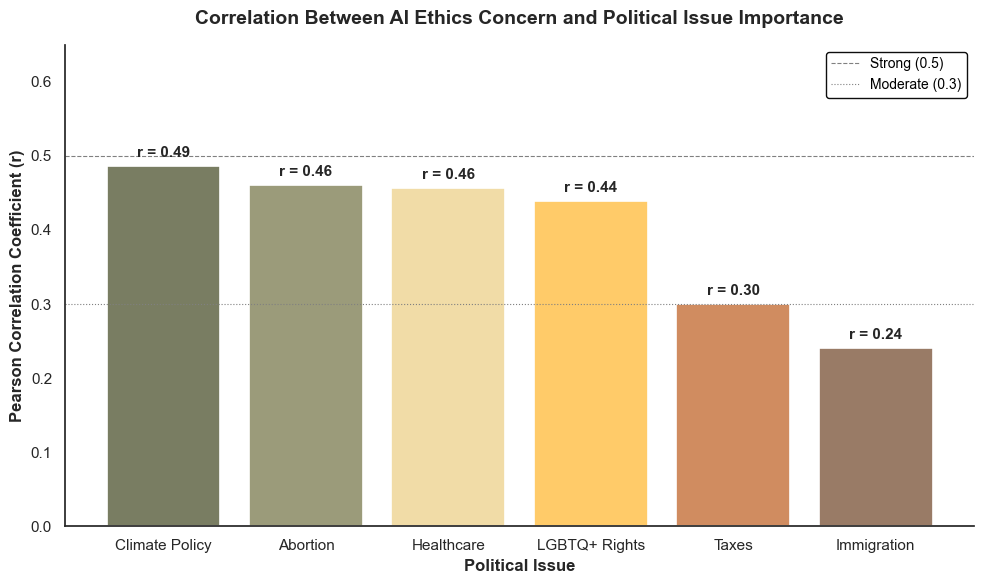

In [41]:
df = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

political_short = ['Immigration', 'Abortion', 'LGBTQ+ Rights', 'Taxes', 'Healthcare', 'Climate Policy']

corr_values = {label: df[ethics_col].corr(df[col]) for col, label in zip(political_cols, political_short)}
corr_series = pd.Series(corr_values).sort_values(ascending=False)

colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(corr_series.index, corr_series.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, corr_series.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008, f'r = {val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Strong (0.5)')
ax.axhline(y=0.3, color='gray', linestyle=':', linewidth=0.8, label='Moderate (0.3)')

ax.set_ylim(0, 0.65)
ax.set_xlabel('Political Issue', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax.set_title('Correlation Between AI Ethics Concern and Political Issue Importance', fontsize=14, fontweight='bold', pad=15)
legend = ax.legend(fontsize=10, loc='upper right', framealpha=0.95, edgecolor='black', fancybox=True)
for text in legend.get_texts():
    text.set_color('black')
legend.get_frame().set_facecolor('white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Visualization Justification: The x axis is our political issue variable, and the y axis is our Pearson correlation coefficient in relation to AI ethics concern. The coefficient ranges from -1 to 1, which indicates the linear relationship of our variables.

Analysis and Conclusion: The bar graph shows that students who hold a higher importance on certain political issues tend to be moderately more concerned about AI ethics on socail media. This relationship is consistent across all political issues, but is most prominant with climate policy. This suggests a connection between environmental concern and AI ethics concern.

## Box Plot Matrix

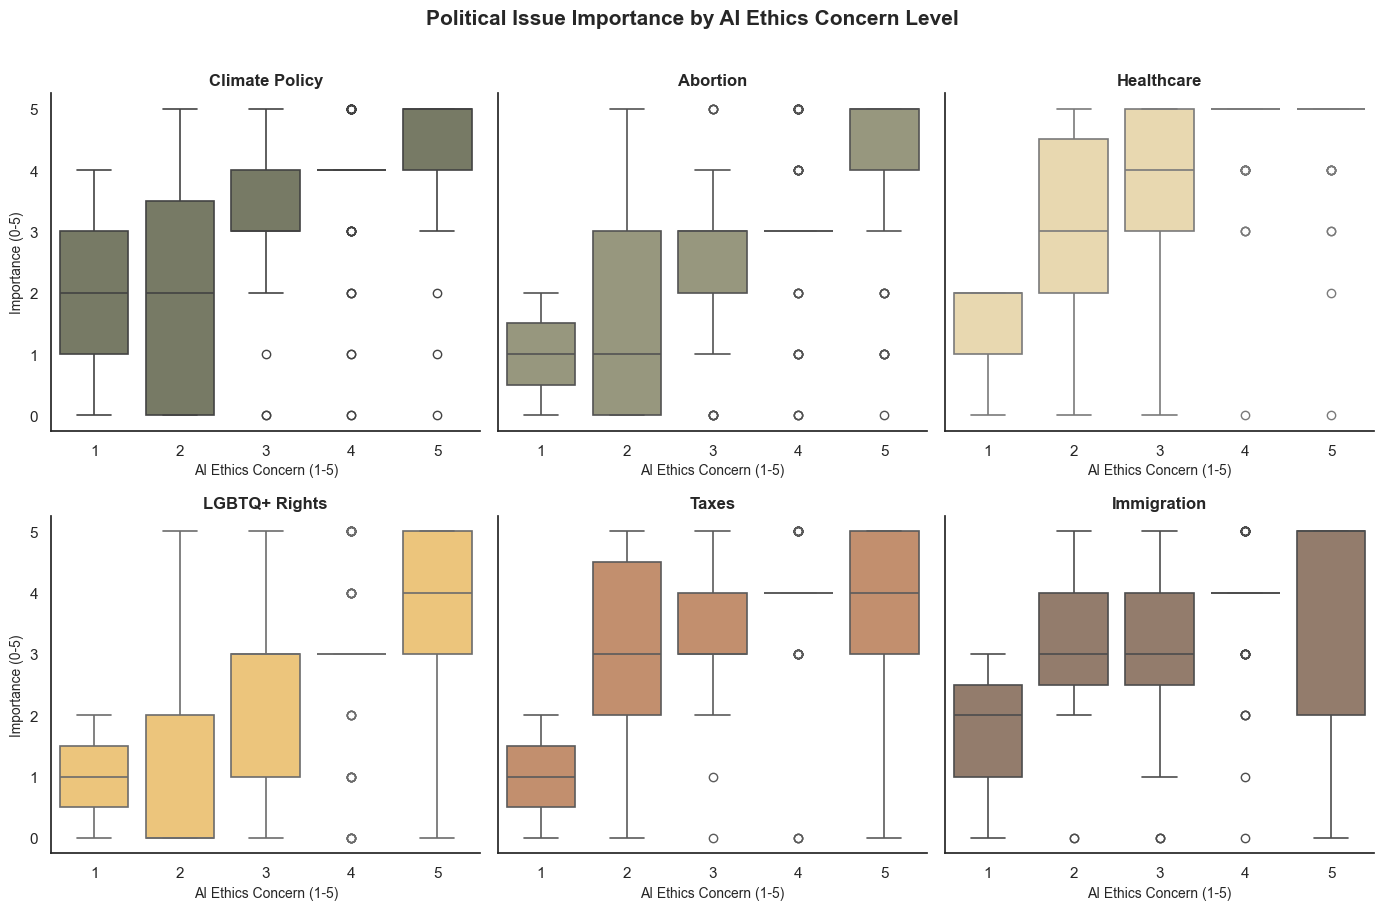

In [42]:
df_pol = pd.read_csv('data_cleaned_ethics_political.csv')

ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
]

political_short = ['Climate Policy', 'Abortion', 'Healthcare', 'LGBTQ+ Rights', 'Taxes', 'Immigration']
colors = ['#797D62', '#9B9B7A', '#F1DCA7', '#FFCB69', '#D08C60', '#997B66']

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(political_cols, political_short, colors)):
    sns.boxplot(data=df_pol, x=ethics_col, y=col, ax=axes[i], color=color, linewidth=1.2)
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('AI Ethics Concern (1-5)', fontsize=10)
    axes[i].set_ylabel('Importance (0-5)' if i % 3 == 0 else '', fontsize=10)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Political Issue Importance by AI Ethics Concern Level', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Box Pot Matrix: Each box plot shows the distribution of a political topic's importance ratings across each level of AI ethics concern, with one cell per political issue. Unlike the bar graph, this plot summarizes the statistics of each individual group (median, IQR, outliers). This better depicts the center of spread across ethics concern levels at a glance. Gathering the political issues into a matrix allows for the comparison of trends of the median.

Analysis: For all 6 political issues, the median importance score of AI ethics concern increases. This confirms the positive correlation shown in the bar chart. Health care has the strongest upward trend, closely followed by climate policy. Immigration and taxes have a more moderate upward trend.

## Ridge Graph

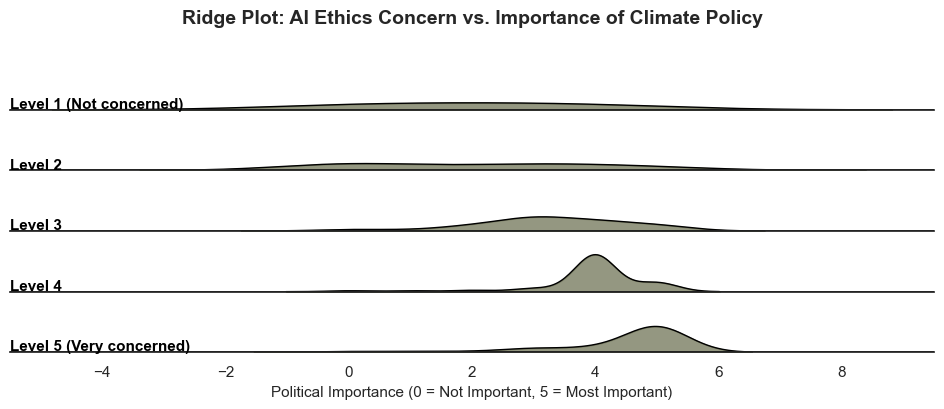

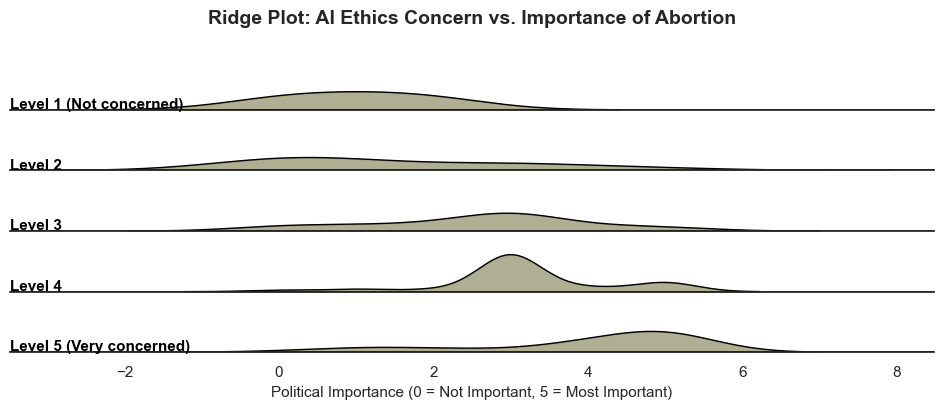

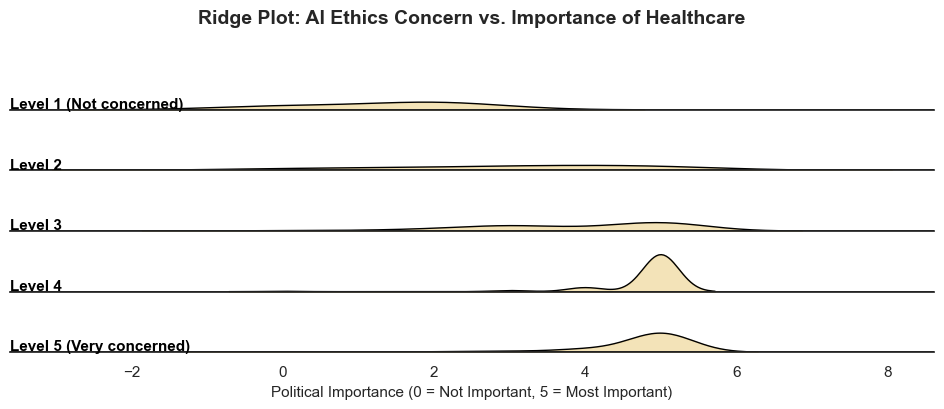

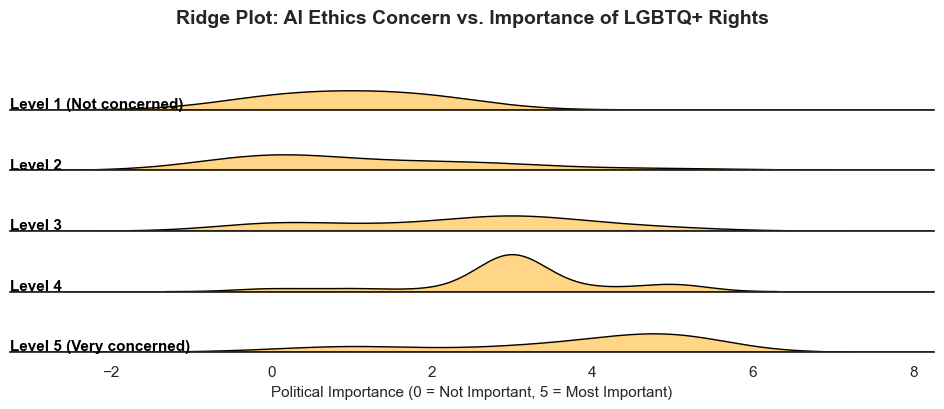

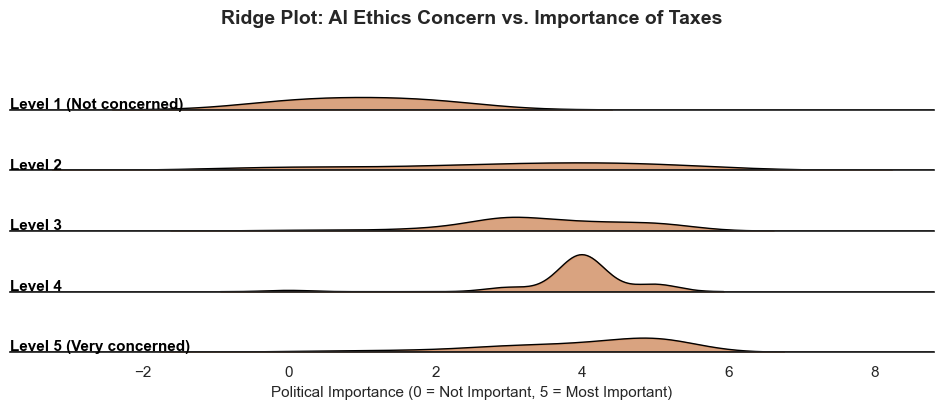

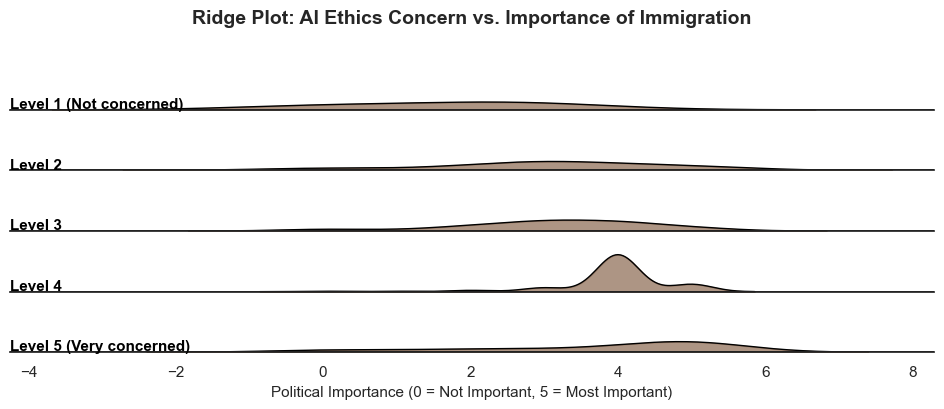

In [43]:
ethics_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, …)'

political_cols = {
    'Climate Policy': 'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
    'Abortion':      'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Healthcare':    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'LGBTQ+ Rights': 'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Taxes':         'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Immigration':   'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
}

issue_colors = {
    'Climate Policy': '#797D62',
    'Abortion':       '#9B9B7A',
    'Healthcare':     '#F1DCA7',
    'LGBTQ+ Rights':  '#FFCB69',
    'Taxes':          '#D08C60',
    'Immigration':    '#997B66',
}

ethics_labels = {
    1: 'Level 1 (Not concerned)',
    2: 'Level 2',
    3: 'Level 3',
    4: 'Level 4',
    5: 'Level 5 (Very concerned)',
}

ethics_order = list(ethics_labels.values())

rows = []
for label, col in political_cols.items():
    sub = df_pol[[ethics_col, col]].dropna().copy()
    sub.columns = ['Ethics Concern', 'Political Importance']
    sub['Political Issue'] = label
    sub['Ethics Level'] = sub['Ethics Concern'].map(ethics_labels)
    rows.append(sub)

long_df = pd.concat(rows, ignore_index=True)
issues = ['Climate Policy', 'Abortion', 'Healthcare', 'LGBTQ+ Rights', 'Taxes', 'Immigration']

for issue in issues:
    issue_df = long_df[long_df['Political Issue'] == issue].copy()

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    g = sns.FacetGrid(
        issue_df,
        row="Ethics Level",
        hue="Ethics Level",
        aspect=12,
        height=0.8,
        palette=[issue_colors[issue]] * len(ethics_order),
        row_order=ethics_order,
        hue_order=ethics_order,
    )

    g.map(sns.kdeplot, "Political Importance", fill=True, alpha=0.8)
    g.map(sns.kdeplot, "Political Importance", color="black", linewidth=1)
    g.map(plt.axhline, y=0, linewidth=2, color="black")

    def label_ridge(x, color, label):
        ax = plt.gca()
        ax.text(0, 0.15, label, fontweight="bold", color="black",
                ha="left", va="center", transform=ax.transAxes, fontsize=11)

    g.map(label_ridge, "Political Importance")

    g.fig.suptitle(
        f"Ridge Plot: AI Ethics Concern vs. Importance of {issue}",
        fontsize=14, fontweight='bold', y=1.02
    )
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set_xlabels("Political Importance (0 = Not Important, 5 = Most Important)", fontsize=11)
    g.despine(left=True)

    plt.tight_layout()
    plt.show()

Ridge plot: The ridge plots show the full distribution of political importance ratings for each level of AI ethics concern (rated 1-5), separetly for each political issue. Instead of displaying a summary stastistic, we chose the ridge plot as it is able to show the distribution shifts as ethics concern increases, such as, whether distributions broaden, sharpen, or shift in location. Each political importance is demonstrated through a ridge based on the level of importance displayed through levels of concern regarding AI.

Analysis: Respondents at lower ethics concern levels (Level 1, Level 2) typically have distributions centered at low importance ratings across all six political issues, whereas respondents at higher ethics concern levels (Level 4, Level 5) exhibit more peaked distributions centered at higher importance values for politics. (add 1-2 sentences on trends). This is supported by the bar chart's showcase that greater AI ethics concern is linked to increased political activity demonstrated through the ridge plot.

## hy1 chi-sq

In [44]:
df_pol = pd.read_csv('data_cleaned_ethics_political.csv')

var1_col = 'How concerned are you about the ethical status of AI generated content on social media? (Misinformation, copyright, \u2026)'

political_cols = [
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Immigration]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Abortion]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [LGBTQ+ Rights]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Taxes]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Healthcare]',
    'Issues in politics/ how important on a scale from 0 (not important) to 5 (the most important) [Climate Policy]',
]

var1 = pd.to_numeric(df[var1_col], errors='coerce')
political_df = df_pol[political_cols].apply(pd.to_numeric, errors='coerce')
var2 = political_df.mean(axis=1)

# Bin var1 (1-5 scale, heavily skewed high) into 2 groups
# Low/Medium (1-3): 61 respondents | High (4-5): 165 respondents
var1_binned = pd.cut(var1, bins=[0.9, 3.5, 5], labels=['Low/Medium (1-3)', 'High (4-5)'])

# Bin var2 (average political importance, 0-5) into 3 groups
var2_binned = pd.cut(var2, bins=[-0.1, 2.5, 3.5, 5.1], labels=['Low (0-2.5)', 'Medium (2.5-3.5)', 'High (3.5-5)'])

contingency_table = pd.crosstab(var1_binned, var2_binned)

alpha = 0.005

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Degrees of Freedom: {dof}")

if p_value < alpha:
    print(f"\nResult: Reject the Null Hypothesis.")
else:
    print(f"\nResult: Fail to reject the Null Hypothesis.")

Chi-Square Statistic: 80.97
P-value: 2.62e-18
Degrees of Freedom: 2

Result: Reject the Null Hypothesis.


Chi-Square Statistic: 80.97 P-value: 0.0000

Result: Reject the Null Hypothesis.

Conclusion: There IS a statistically significant correlation between a student's concern about the ethical status of AI-generated content on social media and the importance they place on political issues.

Hypothesis 1 Overall Conclusion: We reject the null hypothesis. The data demonstrates that the trends from the graphs showing increased political activity are related to concerns about AI ethics. Our visualizations show a relationship between students' concerns about AI's ethical standing and the significance they equate to political issues. The bar chart shows the significance related to the political issue and their concern for AI ethics, climate change, being the highest. This is supported by the ridge plot, which demonstrates the levels of concern for each topic, this way we can compare where the respondents' concerns lie. The box plot matrix is a closer look at the positive linear trend by displaying the center of spread comparisons of the median between each political topic.

## Radar Chart

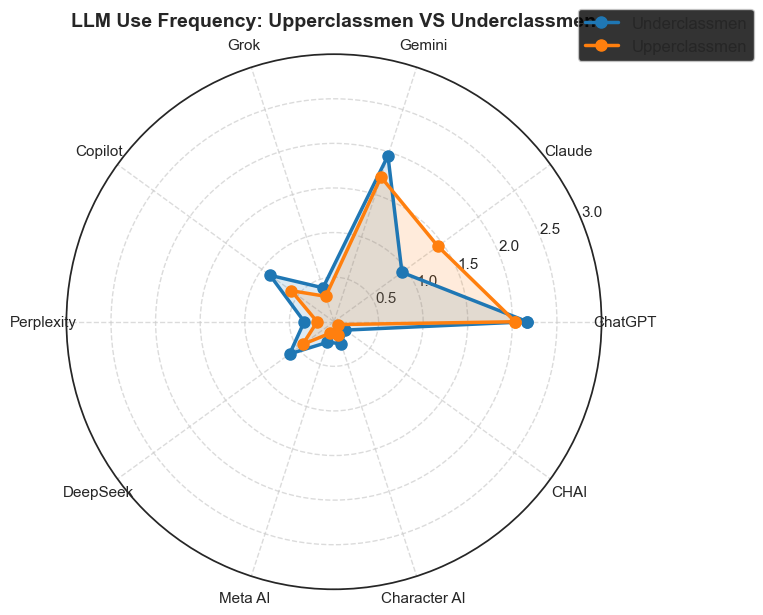

In [45]:
# Set up the radar chart geometry
num_metrics = len(llm_cols)  # Number of metrics (4 in this case)

# Create evenly spaced angles for each axis (in radians)
# endpoint=False means we don't duplicate the starting angle
theta = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)

# Close the polygon by appending the first angle at the end
theta = np.concatenate((theta, [theta[0]]))

# Create the polar plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)  # polar=True creates a circular plot

colors = ['#1f77b4', '#ff7f0e']

for i, group in enumerate(group_names):
    # Get the mean values for this species across all 4 metrics
    values = group_means.loc[group].values

    # Close the polygon by appending the first value at the end
    values = np.concatenate((values, [values[0]]))

    # Plot the line connecting all points
    ax.plot(theta, values, linewidth=2.5, linestyle='solid',
            label=group.capitalize(), color=colors[i], marker='o', markersize=8)

    # Fill the area inside the polygon with transparency
    ax.fill(theta, values, alpha=0.15, color=colors[i])

# Customize the plot
ax.set_xticks(theta[:-1])  # Set tick positions (exclude the duplicate last point)
ax.set_xticklabels(['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot', 'Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI'],
                   fontsize=11)
ax.set_ylim(0, 3)  # Set radial axis limits to accommodate the data range
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('LLM Use Frequency: Upperclassmen VS Underclassmen',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

**This visualization displays the LLMs favored by the two class standings. For example, Upperclassmen use Claude more frequently than Underclassmen. Overall, Underclassmen have higher mean usage frequency of LLMs than Upperclassmen.**

## Heatmap LLM Usage Frequency

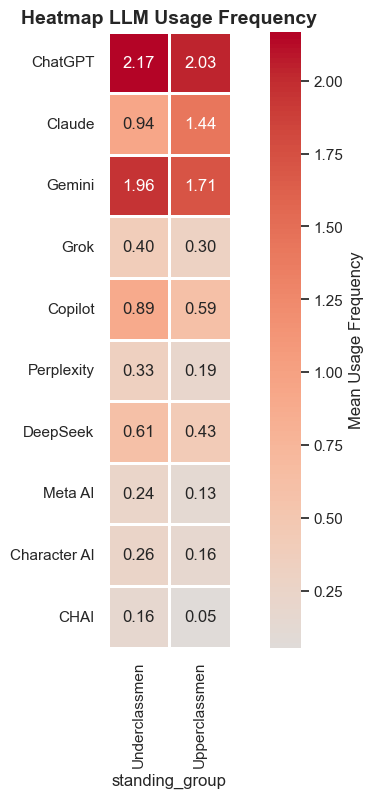

In [46]:
#I USED BOTH THE LAB 5-6 GUIDE TO REFERENCE HOW TO SET UP THE HEATMAP AND ASKED CLAUDE FOR HELP SETTING THE ROWS TO THE LLMS AND 
#THE COLS TO THE CLASS STADING

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
numeric_df = data_df[llm_cols]

#rename columns
llm_names = ['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot','Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI']


#transpose operation, which flips the rows and columns so that
#llm names can be the rows and the class standing can be cols
heat_map = group_means.T
heat_map.index = llm_names

heat_map = heat_map.apply(pd.to_numeric, errors='coerce')

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(heat_map, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Mean Usage Frequency'})

# Add title
plt.title('Heatmap LLM Usage Frequency', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

**This heatmap provides a better visual of which class standing has the overall higher mean usage frequency. For all values besides Claude, Underclassmen have a higher mean usage frequency than Upperclassmen.**

## Chi-Square LLM Usage

In [47]:
#I used the example from the Lab 5-6 guide and asked Claude for help with iterating through the different 
#LLMS for each indiviudal test
from scipy.stats import chi2_contingency, chi2

llm_names = ['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot','Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI']

freq_labels = {0: 'Never Used', 1: 'Used 1-2 Times', 2: 'Use Rarely', 3: 'Use Frequently'}

for col, name in zip(llm_cols, llm_names):

    #Create the contingency table
    contingency = pd.crosstab(data_df['standing_group'], data_df[col])
    contingency.columns = [freq_labels[c] for c in contingency.columns]

    print(f"\nCONTINGENCY TABLE: {name} Usage by Class Standing")
    print("=" * 60)
    print(contingency)
    print("\nRow Totals:", contingency.sum(axis=1).values, "(Underclassmen, Upperclassmen)")
    print("Column Totals:", contingency.sum(axis=0).values)
    print("Grand Total:", contingency.sum().sum(), "students surveyed")

  

    #Perform Chi-Square Test
    chi_stat, p_value, degrees_freedom, expected_freq = chi2_contingency(contingency)
    expected = pd.DataFrame(expected_freq, index=contingency.index, columns=contingency.columns)



    #Display test results
    critical_value = chi2.ppf(0.95, degrees_freedom)
    print("\n" + "=" * 60)
    print(f"CHI-SQUARE TEST RESULTS: {name}")
    print("=" * 60)
    print(f"Chi-Square Statistic (χ²): {chi_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Degrees of Freedom: {degrees_freedom}")
    print(f"\nSignificance Level: α = 0.05")
    print(f"Critical Value at α=0.05: {critical_value:.4f}")

    # Step 5: Interpret the results
    print("\n" + "=" * 60)
    print("INTERPRETATION")
    print("=" * 60)

    if p_value < 0.05:
        print("✓ REJECT the null hypothesis (independence)")
        print(f"  → The p-value ({p_value:.6f}) is less than 0.05")
        print(f"  → The χ² statistic ({chi_stat:.4f}) exceeds the critical value ({critical_value:.4f})")
        print(f"\n  CONCLUSION: Class standing and {name} usage ARE associated!")
        print(f"  There is a statistically significant relationship.")
    else:
        print("✗ FAIL TO REJECT the null hypothesis")
        print(f"  → The p-value ({p_value:.6f}) is greater than 0.05")
        print(f"  → The χ² statistic ({chi_stat:.4f}) is below the critical value ({critical_value:.4f})")
        print(f"\n  CONCLUSION: Cannot conclude that class standing and {name} usage are associated.")
        print("  The data is consistent with independence.")


CONTINGENCY TABLE: ChatGPT Usage by Class Standing
                Never Used  Used 1-2 Times  Use Rarely  Use Frequently
standing_group                                                        
Underclassmen            5              12          20              34
Upperclassmen           17              24          46              63

Row Totals: [ 71 150] (Underclassmen, Upperclassmen)
Column Totals: [22 36 66 97]
Grand Total: 221 students surveyed

CHI-SQUARE TEST RESULTS: ChatGPT
Chi-Square Statistic (χ²): 1.3966
P-value: 0.706326
Degrees of Freedom: 3

Significance Level: α = 0.05
Critical Value at α=0.05: 7.8147

INTERPRETATION
✗ FAIL TO REJECT the null hypothesis
  → The p-value (0.706326) is greater than 0.05
  → The χ² statistic (1.3966) is below the critical value (7.8147)

  CONCLUSION: Cannot conclude that class standing and ChatGPT usage are associated.
  The data is consistent with independence.

CONTINGENCY TABLE: Claude Usage by Class Standing
                Never Used 

**After performing the test on each LLM, we cannot conclude for most LLMS (7/10) that they are correlated. Despite visualizations, the test shows us that class standing and LLM mean frequency usage are likely not correlated. The conclusion leads to fail to reject the null hypothesis. However, I still believe there is interesting information to take away with the 3 LLMS that are associated with class standing. For instance, Claude is associated with class standing and is used significantly more frequently by upperclassmen then underclassmen.**

## Distribution of Gender Bar Chart

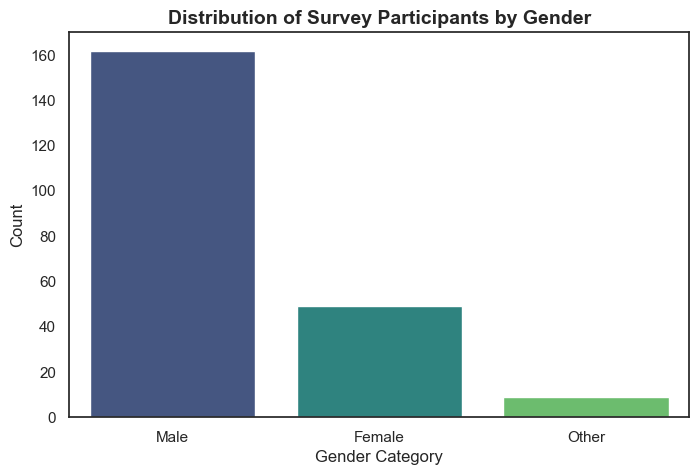

In [48]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_trim, x='Gender', palette='viridis', order=['Male', 'Female', 'Other'])
plt.title('Distribution of Survey Participants by Gender' ,fontsize=14, fontweight='bold')
plt.xlabel('Gender Category', fontsize = 12)
plt.ylabel('Count', fontsize = 12)

plt.show()

## Stacked Bar Chart: Gender v.s. Rounded Average Sentiment

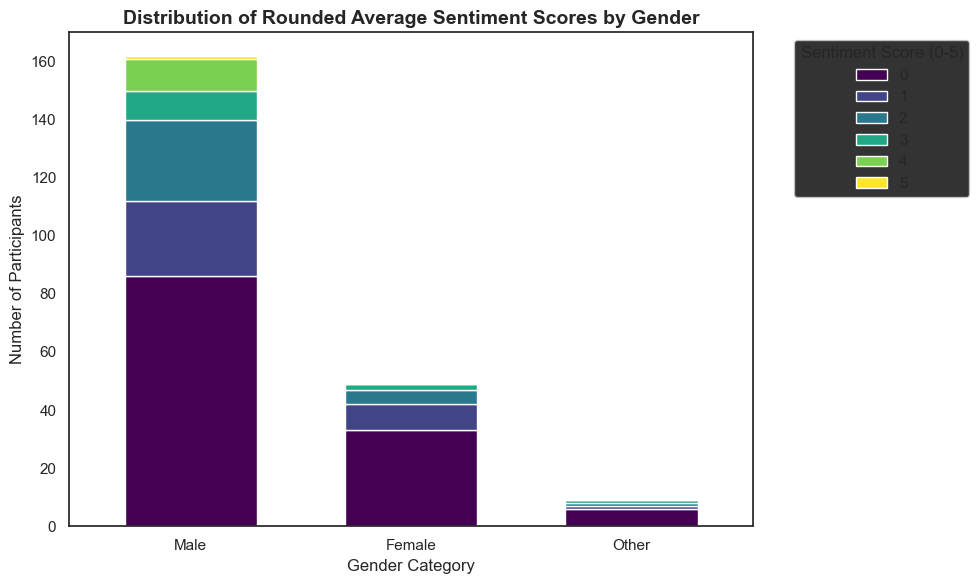

In [49]:
# create crosstab counts of gender vs rounded sentiments
sentiment_by_gender = pd.crosstab(df_trim['Gender'], df_trim['Rounded_Sentiment'])
sentiment_by_gender = sentiment_by_gender.reindex(['Male', 'Female', 'Other'])

# set axis
ax = sentiment_by_gender.plot(
    kind='bar', 
    stacked=True, 
    colormap='viridis', 
    figsize=(10, 6), 
    width=0.6,
)

# titles and labels
plt.title('Distribution of Rounded Average Sentiment Scores by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender Category', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)

# set legend aside from bars
plt.legend(title='Sentiment Score (0-5)', bbox_to_anchor=(1.05, 1), loc='upper left')
# roate legend
plt.xticks(rotation=0)
# prevent cutoff
plt.tight_layout()

plt.show()

## Violin Plot Matrix

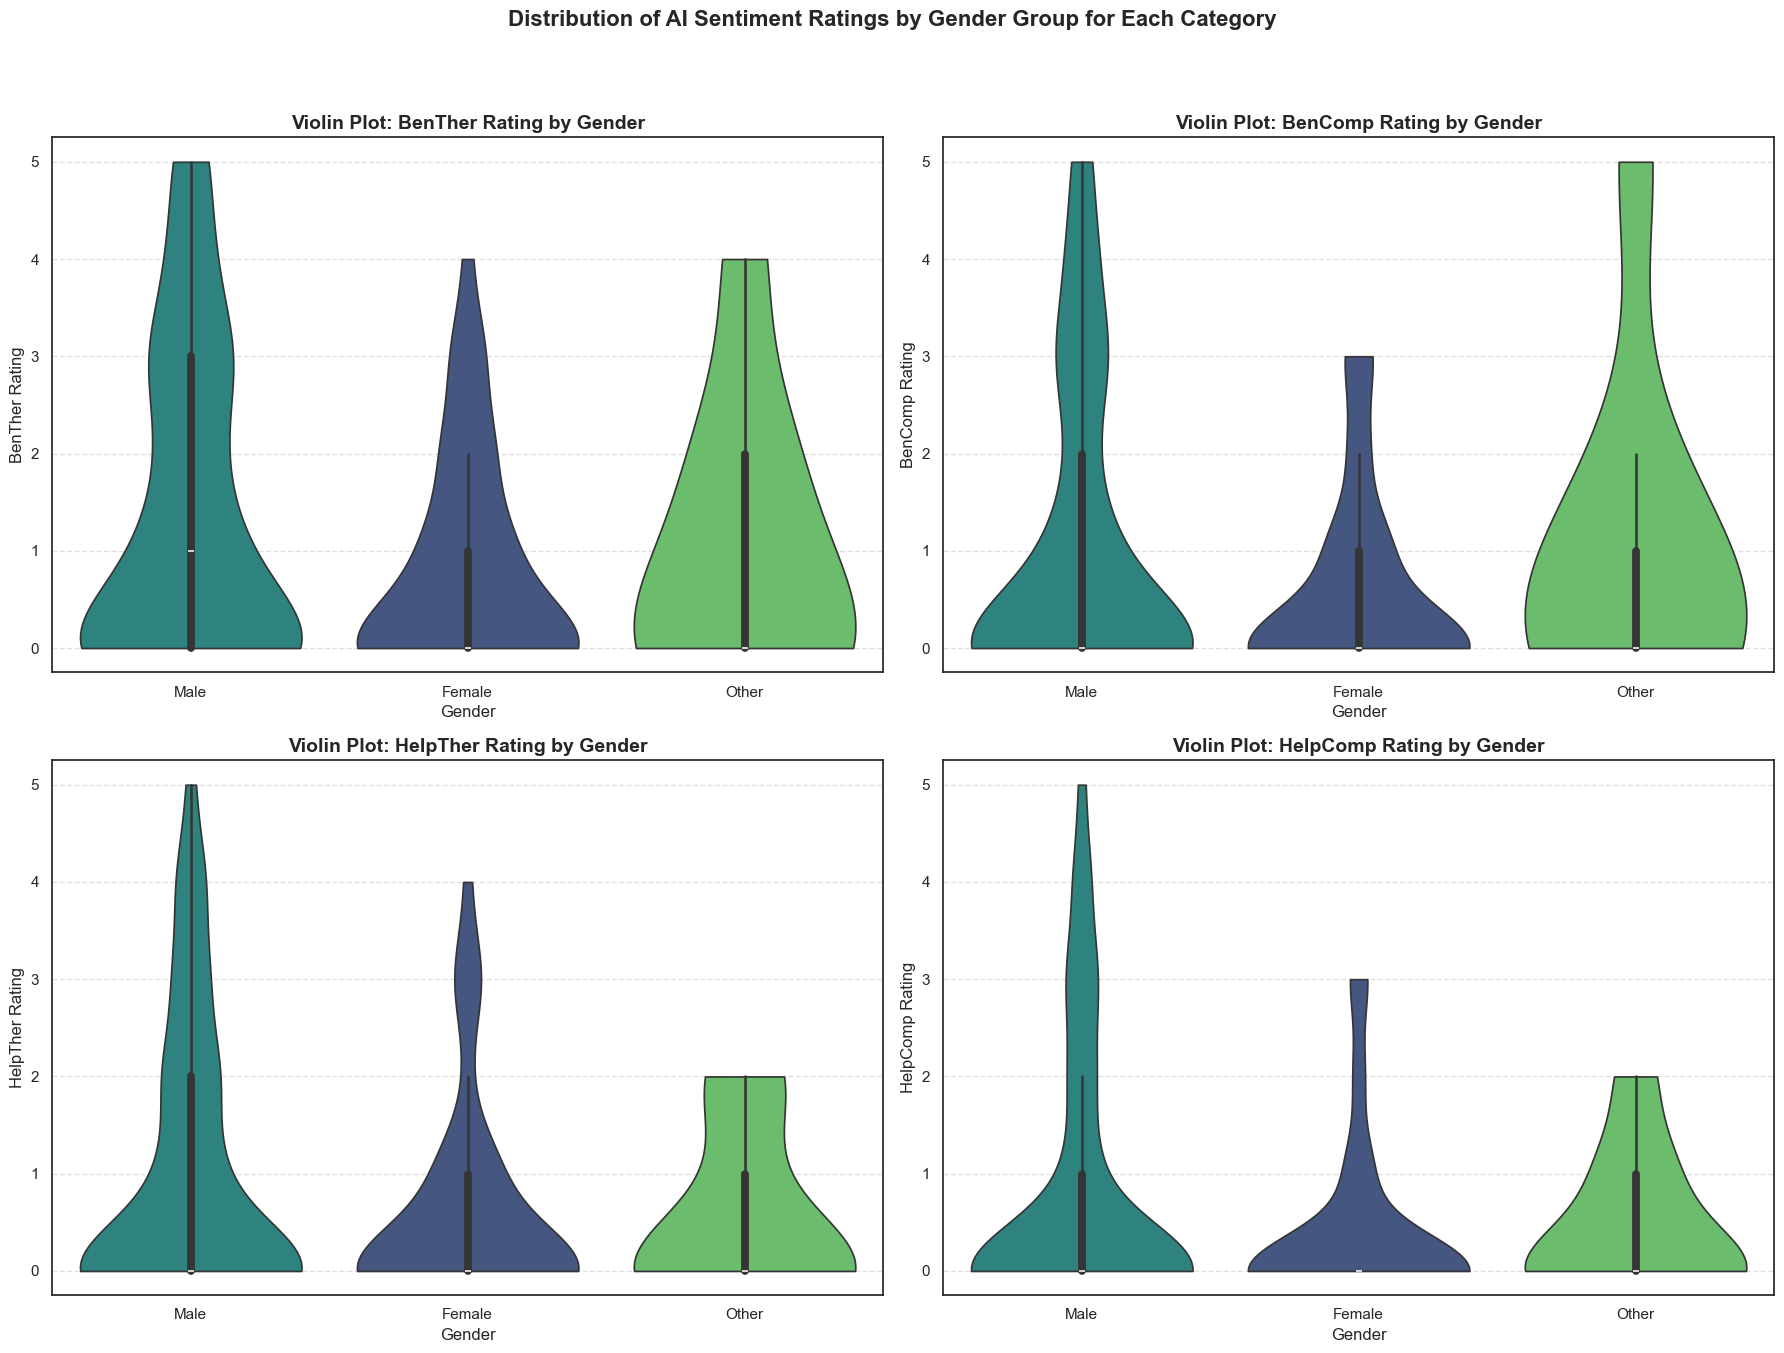

In [50]:
sentiment_columns = ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']

fig, axes = plt.subplots(2, 2, figsize=(18, 14)) # Create a new figure and 2x2 subplots
fig.suptitle('Distribution of AI Sentiment Ratings by Gender Group for Each Category', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, col in enumerate(sentiment_columns):
    sns.violinplot(x='Gender', y=col, data=df_trim,
                   inner='box', palette='viridis', order=['Male', 'Female', 'Other'],
                   hue='Gender', legend=False, cut=0, ax=axes[i])

    # Add labels and title
    axes[i].set_xlabel('Gender', fontsize=12)
    axes[i].set_ylabel(f'{col} Rating', fontsize=12)
    axes[i].set_title(f'Violin Plot: {col} Rating by Gender',
                      fontsize=14, fontweight='bold')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

**Violin Plot Matrix**: These violin plots represent the different weights of answers for each of the questions related to the sentiment of AI in theraputic and companionship.

**Analysis and Conclusion**:These graphs show the distrubition of weight between answers of each gendered group. For all the graphs we can see that males have a slightly higher weight on ratings above 3, while females and others are typically returning lower ratings at 3 or lower.

## Correlation Heatmap: Gender v.s. Sentiment

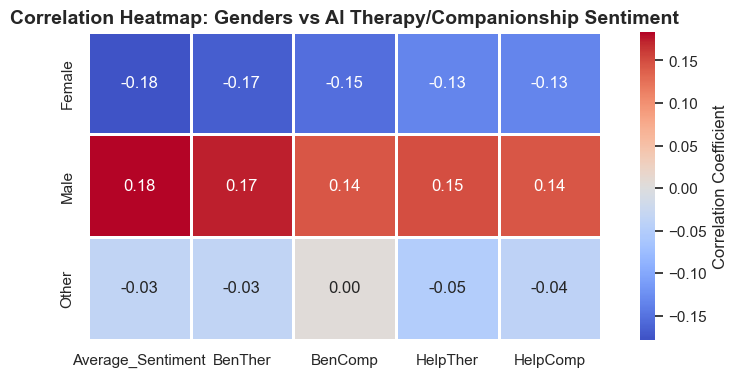

In [51]:
# Create a correlation heatmap to visualize relationships between all numeric variables

# categorize into male, female, other columns (assisted by Google Gemini LLM)
df_encoded = pd.get_dummies(df_trim, columns=['Gender'], dtype=int)
df_encoded = df_encoded.rename(columns={
    'Gender_Female': 'Female',
    'Gender_Male': 'Male',
    'Gender_Other': 'Other'
})

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
# numeric_df = df.select_dtypes(include=[np.number])
genders = ['Female', 'Male', 'Other']
sentiments = ['Average_Sentiment', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']

heatmap_cols = ['Female', 'Male', 'Other', 'Average_Sentiment', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']
df_numeric = df_encoded[heatmap_cols]

# calculate the pairwise pearson's correlation of multiple columns. 'r' is the correlation matrix calculated
# full correlation matrix
full_corr = df_encoded[genders + sentiments].corr()
# correlation between gender and sentiments lists
gen_sent_corr = full_corr.loc[genders, sentiments]

# Set figure size for better readability
plt.figure(figsize=(10, 4))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(gen_sent_corr, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap: Genders vs AI Therapy/Companionship Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

## Chi-Square Test

In [52]:
# create contingency table
contingency_table = pd.crosstab(df_trim['Gender'], df_trim['Rounded_Sentiment'])

# use contingency to run chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# print statistic
print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant correlation between gender and sentiment towards the use of AI as a therapeutic service or companionship.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: There is no significant correlation between gender and sentiment towards the use of AI as a therapeutic service or companionship.")

Chi-Square Statistic: 8.13
P-value: 0.6164

Result: Fail to reject the Null Hypothesis.
Conclusion: There is no significant correlation between gender and sentiment towards the use of AI as a therapeutic service or companionship.
